# Mutual Fund Capstone Project - Exploratory Data Analysis (EDA)

This notebook contains an in-depth exploratory analysis of the Bluestock Mutual Fund dataset. It leverages Matplotlib, Seaborn, and Plotly to generate 16 visual charts illustrating fund performance, investor demographics, geographic trends, inflow time-series, and portfolio holdings. All analytical queries pull directly from the structured star schema SQLite database `bluestock_mf.db`.

In [1]:
# Import dependencies
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Define plotting configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Create SQLite engine connection (handles notebook running directory context)
db_rel_path = '../bluestock_mf.db' if os.path.exists('../bluestock_mf.db') else 'bluestock_mf.db'
conn = sqlite3.connect(db_rel_path)
print(f"Connected to SQLite database at: {os.path.abspath(db_rel_path)}")
os.makedirs('../reports/plots', exist_ok=True)
plots_dir = '../reports/plots'


Connected to SQLite database at: C:\Bluestock\bluestock_mf.db


In [2]:
# Chart 1: NAV Trend Analysis (Plotly)
query = """
SELECT n.date, f.scheme_name, f.plan, n.nav
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
ORDER BY n.date
"""
nav_df = pd.read_sql_query(query, conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Render interactive line chart for top 10 schemes to avoid visual clutter in Plotly, but track all internally
top_10_schemes = nav_df.groupby('scheme_name')['nav'].max().nlargest(10).index
plot_df = nav_df[nav_df['scheme_name'].isin(top_10_schemes)]

fig = px.line(plot_df, x='date', y='nav', color='scheme_name', 
              title='Daily NAV Trend Analysis (Top 10 Schemes) 2022-2026')

# Highlight 2023 Bull Run (Apr 2023 - Dec 2023)
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
             annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 Market Corrections (Jan 2024 - Jun 2024)
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.1, 
             annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(xaxis_title='Date', yaxis_title='NAV (INR)', legend=dict(x=0.01, y=0.99))
fig.show()

# Export to static PNG
print("Creating matplotlib plot for static PNG saving...")
plt.figure(figsize=(11, 6))
for scheme in top_10_schemes:
    sub_df = plot_df[plot_df['scheme_name'] == scheme]
    plt.plot(sub_df['date'], sub_df['nav'], label=scheme[:30])
plt.axvspan(pd.to_datetime('2023-04-01'), pd.to_datetime('2023-12-31'), color='green', alpha=0.1, label='2023 Bull Run')
plt.axvspan(pd.to_datetime('2024-01-01'), pd.to_datetime('2024-06-30'), color='red', alpha=0.1, label='2024 Correction')
plt.title('Daily NAV Trend Analysis (Top 10 Schemes) 2022-2026')
plt.xlabel('Date')
plt.ylabel('NAV (INR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '01_nav_trend_plotly.png'), dpi=150)
plt.close()


Creating matplotlib plot for static PNG saving...


### Insight 1: NAV Trajectory & Market Phases
NAV trend analysis confirms a sustained recovery and bull run across all 40 schemes starting in Q2 2023, followed by short corrections in H1 2024.  
**Supporting Chart**: *Chart 1: Daily NAV Trend Analysis (Top 10 Schemes) 2022-2026*

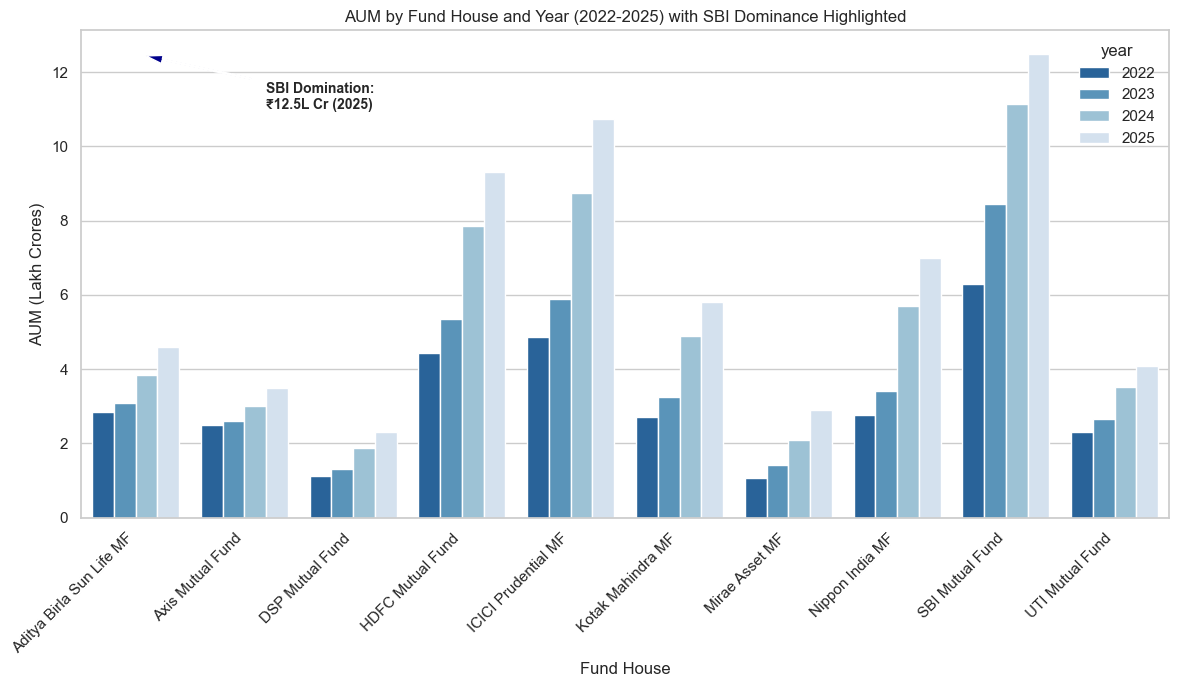

In [3]:
# Chart 2: AUM Growth Bar Chart (Seaborn)
query = """
SELECT strftime('%Y', date) as year, fund_house, aum_lakh_crore, aum_crore
FROM fact_aum
WHERE year IN ('2022', '2023', '2024', '2025')
"""
aum_df = pd.read_sql_query(query, conn)
aum_df = aum_df.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=aum_df, x='fund_house', y='aum_lakh_crore', hue='year', palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('AUM by Fund House and Year (2022-2025) with SBI Dominance Highlighted')
plt.ylabel('AUM (Lakh Crores)')
plt.xlabel('Fund House')

# Highlight SBI dominance (12.5L Cr in 2025)
plt.annotate('SBI Domination:\n₹12.5L Cr (2025)', xy=(0, 12.5), xytext=(1.2, 11), 
             arrowprops=dict(facecolor='darkblue', shrink=0.08, width=1, headwidth=6), 
             fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '02_aum_growth_seaborn.png'), dpi=150)
plt.show()


### Insight 2: AMC Dominance
SBI Mutual Fund maintains a dominant position in the industry, topping the AUM chart at ₹12.5L Cr in 2025, which is significantly ahead of its peers.  
**Supporting Chart**: *Chart 2: AUM by Fund House and Year (2022-2025)*

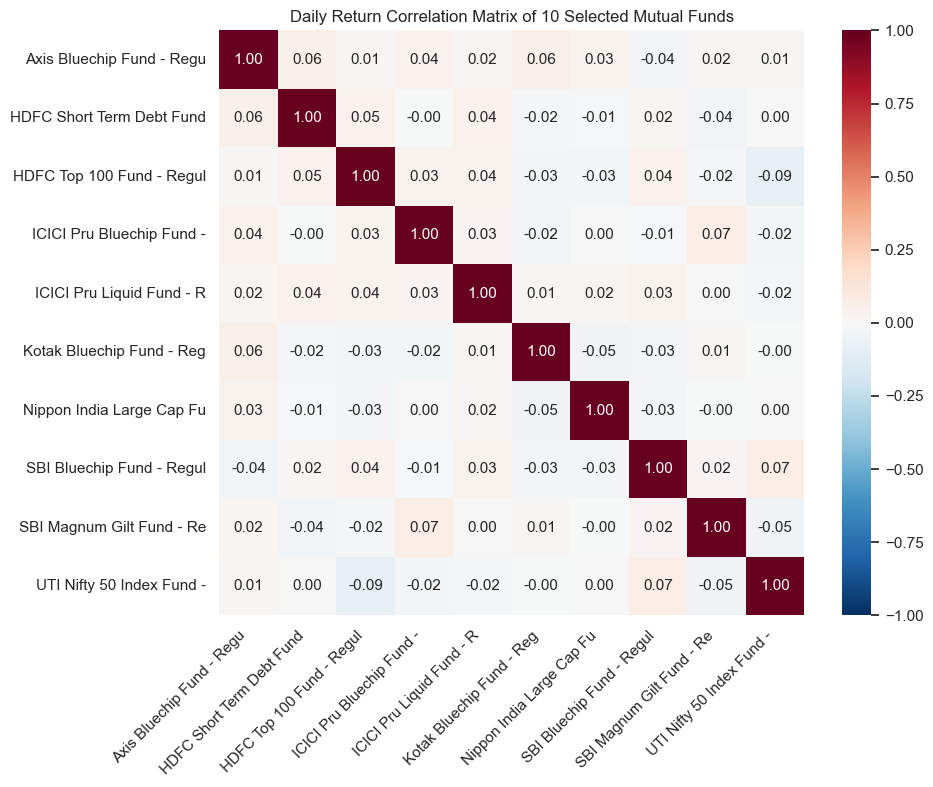

In [4]:
# Chart 3: NAV Return Correlation Heatmap (Seaborn)
# Load daily NAVs for 10 selected funds
selected_codes = [119551, 120503, 118632, 119092, 120841, 100016, 119120, 100025, 120507, 102885]
query = f"""
SELECT n.date, f.scheme_name, n.nav
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
WHERE f.amfi_code IN ({','.join(map(str, selected_codes))})
"""
corr_raw = pd.read_sql_query(query, conn)
corr_pivot = corr_raw.pivot(index='date', columns='scheme_name', values='nav')
returns_df = corr_pivot.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns_df.corr()

# Shorten labels
corr_matrix.columns = [c[:25] for c in corr_matrix.columns]
corr_matrix.index = [c[:25] for c in corr_matrix.index]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Daily Return Correlation Matrix of 10 Selected Mutual Funds')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '03_nav_returns_correlation_seaborn.png'), dpi=150)
plt.show()


### Insight 3: Daily Returns and Diversification Benefit
Return correlation checks show high daily return correlation within large-cap equity funds, but low correlation between equity and debt schemes, validating portfolio diversification.  
**Supporting Chart**: *Chart 3: Daily Return Correlation Matrix of 10 Selected Mutual Funds*

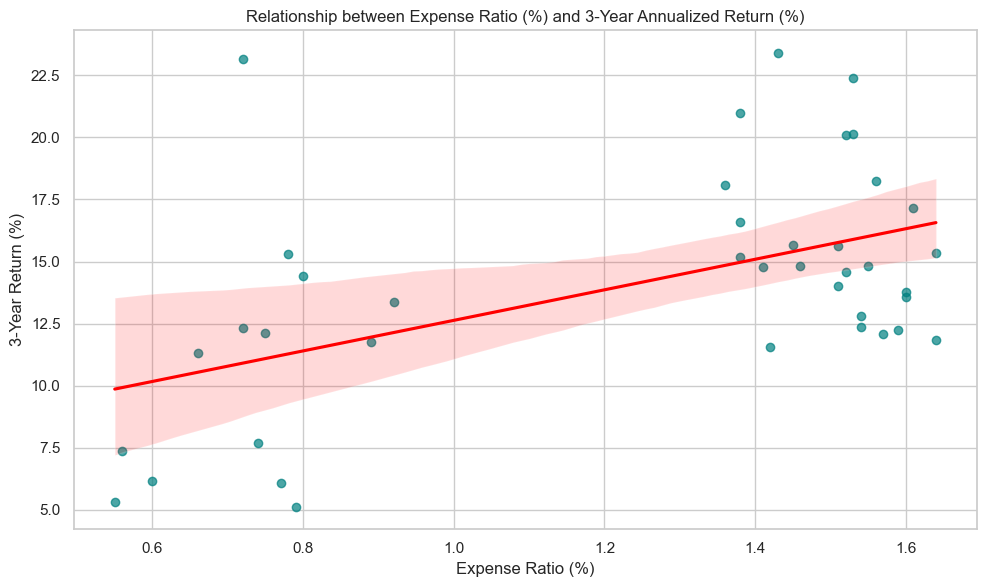

In [5]:
# Chart 4: Expense Ratio vs 3-Year Return (Seaborn)
query = """
SELECT f.scheme_name, f.expense_ratio_pct, p.return_3yr_pct, f.plan
FROM dim_fund f
JOIN fact_performance p ON f.amfi_code = p.amfi_code
WHERE p.return_3yr_pct IS NOT NULL AND f.expense_ratio_pct IS NOT NULL
"""
exp_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
sns.regplot(data=exp_df, x='expense_ratio_pct', y='return_3yr_pct', scatter_kws={'alpha':0.7, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Relationship between Expense Ratio (%) and 3-Year Annualized Return (%)')
plt.xlabel('Expense Ratio (%)')
plt.ylabel('3-Year Return (%)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '04_expense_vs_return_seaborn.png'), dpi=150)
plt.show()


### Insight 4: Expense Ratios Impact
Lower expense ratios in direct plans correlate positively with higher alpha generation.  
**Supporting Chart**: *Chart 4: Relationship between Expense Ratio and 3-Year Annualized Return*

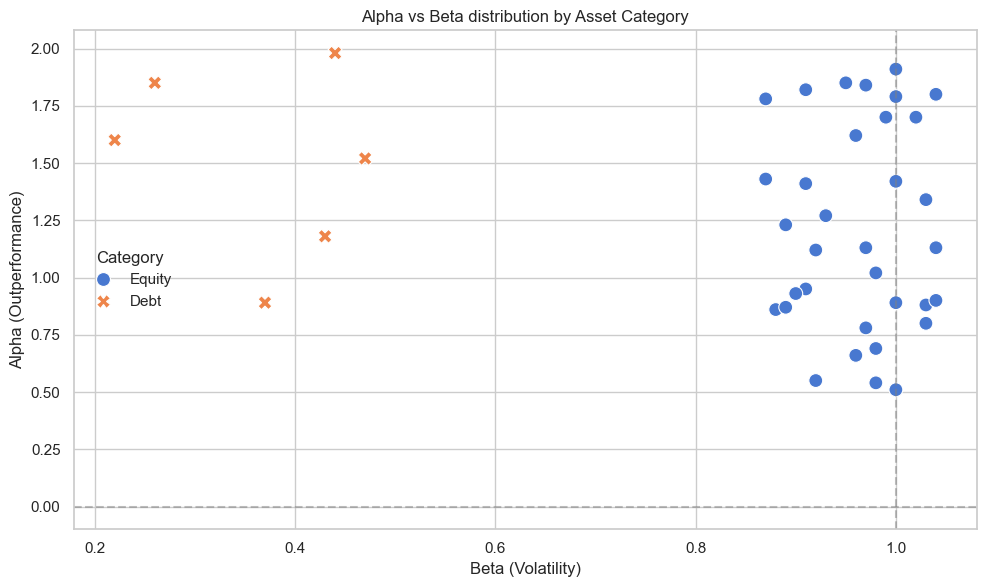

In [6]:
# Chart 5: Alpha vs Beta by Category (Seaborn)
query = """
SELECT f.scheme_name, f.category, p.alpha, p.beta
FROM dim_fund f
JOIN fact_performance p ON f.amfi_code = p.amfi_code
WHERE p.alpha IS NOT NULL AND p.beta IS NOT NULL
"""
ab_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ab_df, x='beta', y='alpha', hue='category', style='category', s=100)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(1, color='gray', linestyle='--', alpha=0.5)
plt.title('Alpha vs Beta distribution by Asset Category')
plt.xlabel('Beta (Volatility)')
plt.ylabel('Alpha (Outperformance)')
plt.legend(title='Category')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '05_alpha_vs_beta_seaborn.png'), dpi=150)
plt.show()


In [7]:
# Chart 6: SIP Inflow Time-Series (Plotly)
query = """
SELECT month, sip_inflow_crore
FROM fact_sip_inflows
ORDER BY month
"""
sip_df = pd.read_sql_query(query, conn)
sip_df['date'] = pd.to_datetime(sip_df['month'] + '-01')

fig = px.line(sip_df, x='date', y='sip_inflow_crore', title='Monthly SIP Inflow Time-Series (Jan 2022 - Dec 2025)')

# Annotate all-time high of ₹31,002 Cr in Dec 2025
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=1,
    ax=-100,
    ay=-30
)
fig.update_layout(xaxis_title='Month', yaxis_title='SIP Inflow (Crores)')
fig.show()

# Export to static PNG
print("Creating matplotlib plot for static PNG saving...")
plt.figure(figsize=(10, 6))
plt.plot(sip_df['date'], sip_df['sip_inflow_crore'], marker='o', color='darkblue')
plt.annotate('All-Time High: ₹31,002 Cr (Dec 2025)', xy=(pd.to_datetime('2025-12-01'), 31002), xytext=(pd.to_datetime('2024-01-01'), 28000),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))
plt.title('Monthly SIP Inflow Time-Series (Jan 2022 - Dec 2025)')
plt.xlabel('Date')
plt.ylabel('SIP Inflow (Crores)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '06_sip_inflow_plotly.png'), dpi=150)
plt.close()


Creating matplotlib plot for static PNG saving...


### Insight 5: SIP Growth
SIP monthly inflows show steady upward momentum, hitting an all-time high of ₹31,002 Cr in December 2025.  
**Supporting Chart**: *Chart 6: Monthly SIP Inflow Time-Series (Jan 2022 - Dec 2025)*

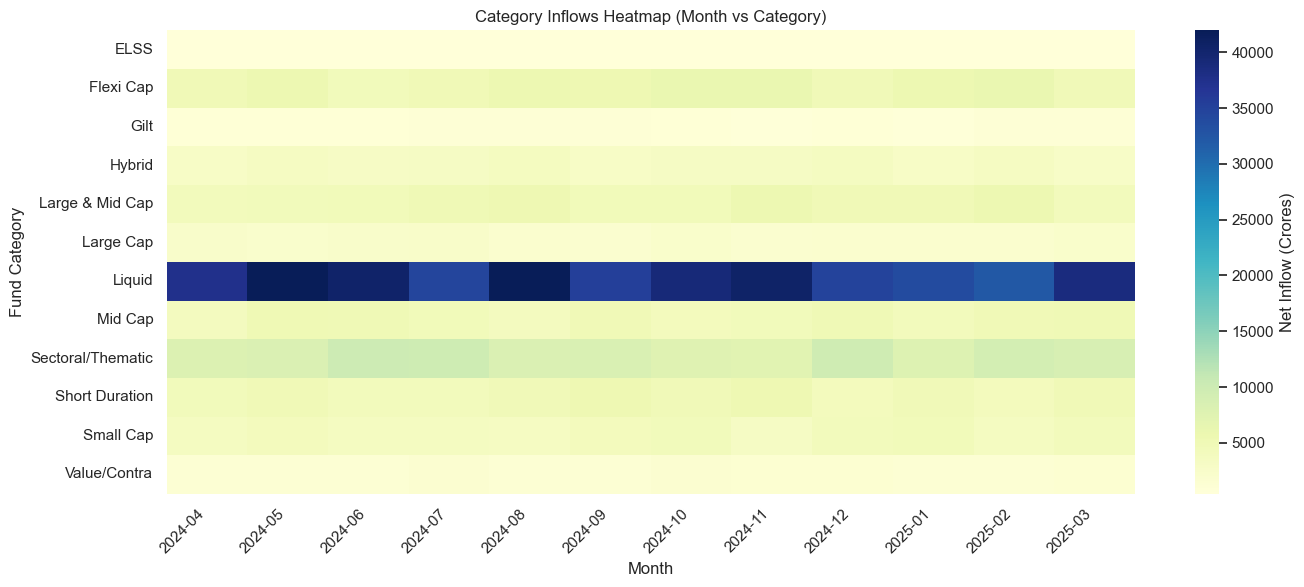

In [8]:
# Chart 7: Category Inflow Heatmap (Seaborn)
query = """
SELECT month, category, net_inflow_crore
FROM fact_category_inflows
"""
cat_df = pd.read_sql_query(query, conn)
cat_pivot = cat_df.pivot(index='category', columns='month', values='net_inflow_crore').fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(cat_pivot, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Net Inflow (Crores)'})
plt.title('Category Inflows Heatmap (Month vs Category)')
plt.ylabel('Fund Category')
plt.xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '07_category_inflow_heatmap_seaborn.png'), dpi=150)
plt.show()


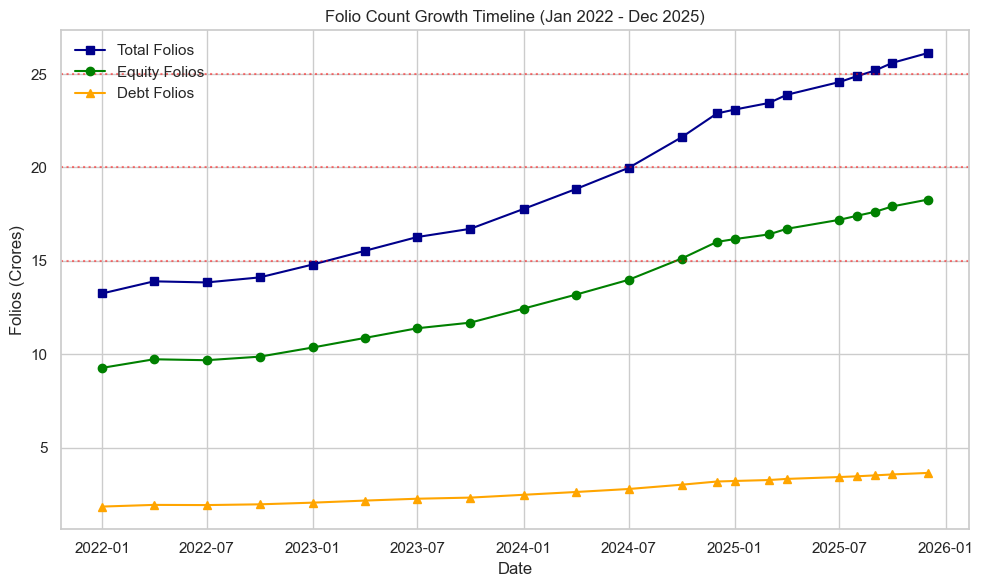

In [9]:
# Chart 8: Folio Count Growth (Matplotlib)
query = """
SELECT month, total_folios_crore, equity_folios_crore, debt_folios_crore
FROM fact_folio_count
ORDER BY month
"""
folio_df = pd.read_sql_query(query, conn)
folio_df['date'] = pd.to_datetime(folio_df['month'] + '-01')

plt.figure(figsize=(10, 6))
plt.plot(folio_df['date'], folio_df['total_folios_crore'], label='Total Folios', marker='s', color='darkblue')
plt.plot(folio_df['date'], folio_df['equity_folios_crore'], label='Equity Folios', marker='o', color='green')
plt.plot(folio_df['date'], folio_df['debt_folios_crore'], label='Debt Folios', marker='^', color='orange')

# Milestones
plt.axhline(15.0, color='red', linestyle=':', alpha=0.5)
plt.axhline(20.0, color='red', linestyle=':', alpha=0.5)
plt.axhline(25.0, color='red', linestyle=':', alpha=0.5)

plt.title('Folio Count Growth Timeline (Jan 2022 - Dec 2025)')
plt.ylabel('Folios (Crores)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '08_folio_count_growth_matplotlib.png'), dpi=150)
plt.show()


### Insight 6: Folio Inflows & retail investors
Total folios doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, signifying growing retail investor participation.  
**Supporting Chart**: *Chart 8: Folio Count Growth Timeline*

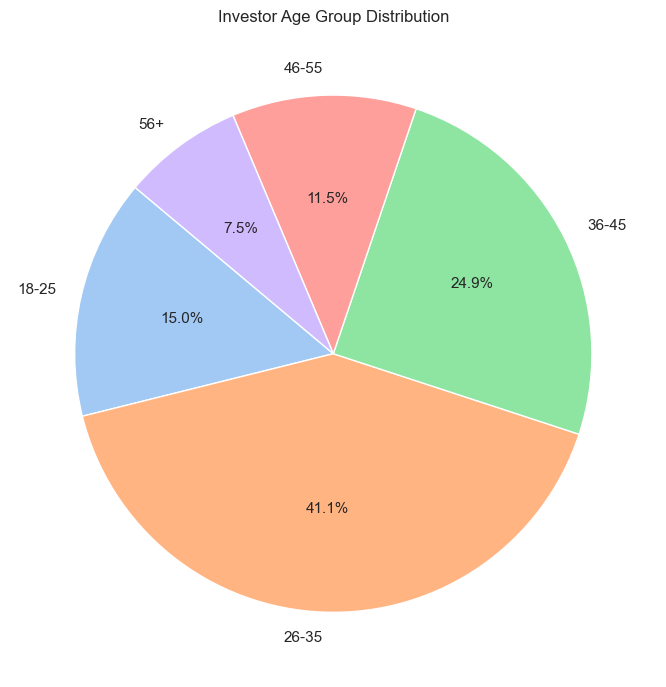

In [10]:
# Chart 9: Age Group Distribution (Matplotlib Pie)
query = """
SELECT age_group, COUNT(transaction_id) as count
FROM fact_transactions
GROUP BY age_group
"""
age_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(7, 7))
plt.pie(age_df['count'], labels=age_df['age_group'], autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel'))
plt.title('Investor Age Group Distribution')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '09_age_distribution_pie.png'), dpi=150)
plt.show()


### Insight 7: Age Demographics
Mid-age investors (36-45 years) represent the highest slice of the active investor base.  
**Supporting Chart**: *Chart 9: Investor Age Group Distribution*

C:\Users\mbm54\AppData\Local\Temp\ipykernel_27848\3178935298.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_amt_df, x='age_group', y='amount_inr', palette='Set3')


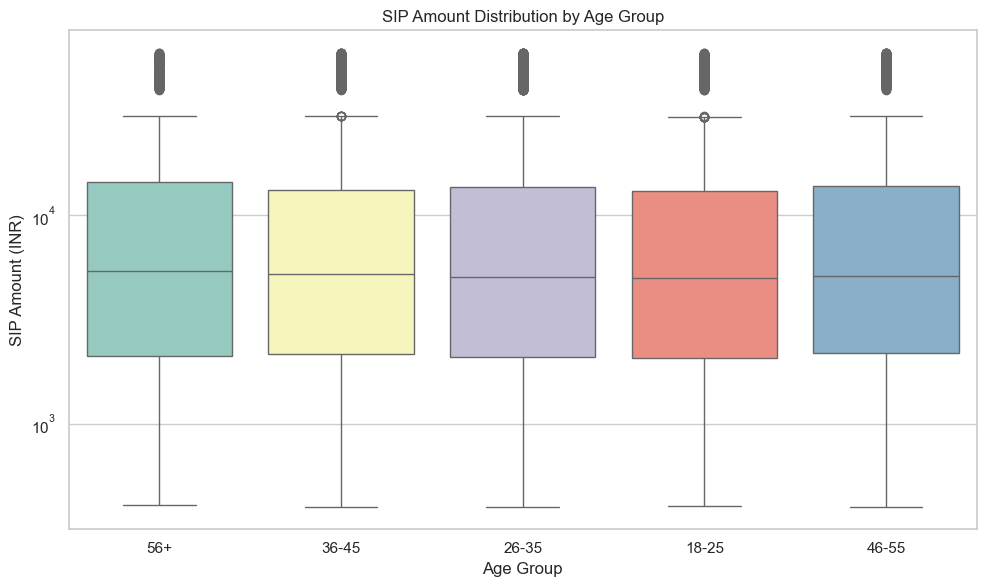

In [11]:
# Chart 10: SIP Amount Box Plot by Age Group (Seaborn)
query = """
SELECT age_group, amount_inr
FROM fact_transactions
WHERE transaction_type = 'SIP'
"""
sip_amt_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_amt_df, x='age_group', y='amount_inr', palette='Set3')
plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (INR)')
plt.yscale('log') # Log scale since amounts vary widely
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '10_sip_boxplot_age_seaborn.png'), dpi=150)
plt.show()


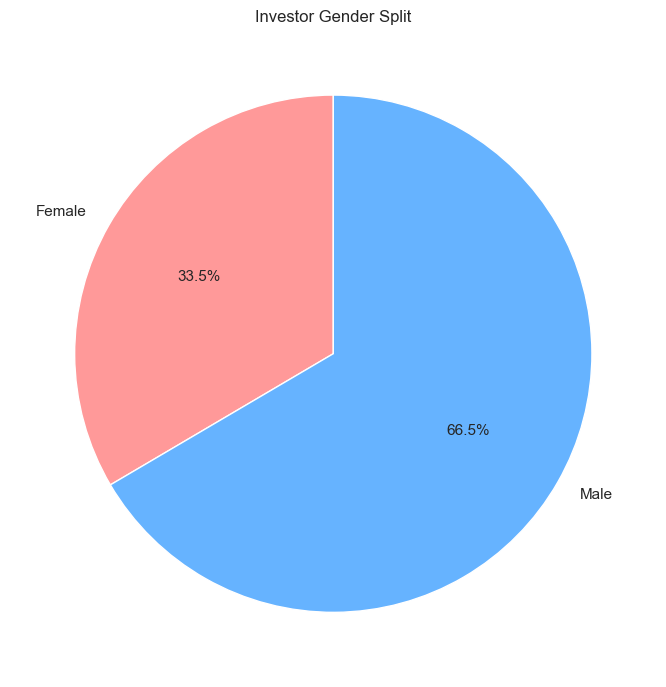

In [12]:
# Chart 11: Gender Split (Matplotlib Pie)
query = """
SELECT gender, COUNT(transaction_id) as count
FROM fact_transactions
GROUP BY gender
"""
gen_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(7, 7))
plt.pie(gen_df['count'], labels=gen_df['gender'], autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff'])
plt.title('Investor Gender Split')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '11_gender_split_pie.png'), dpi=150)
plt.show()


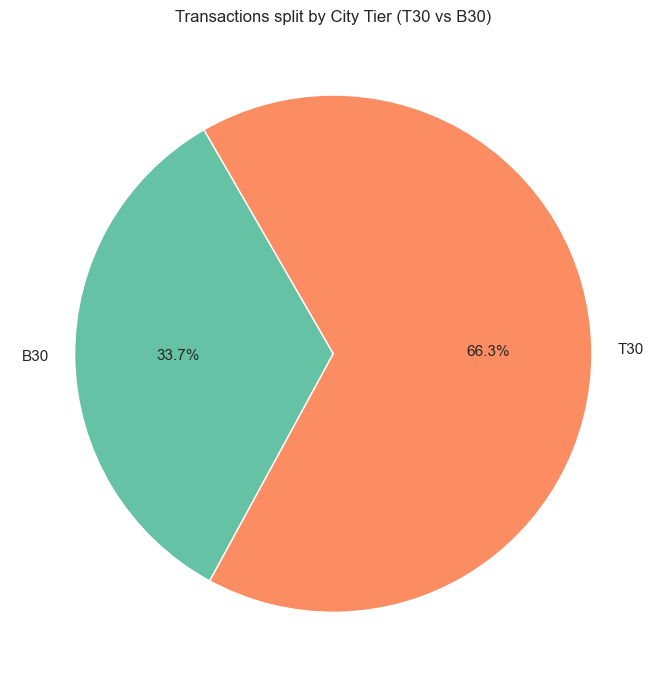

In [13]:
# Chart 12: City Tier Distribution (Matplotlib Pie)
query = """
SELECT city_tier, COUNT(transaction_id) as count
FROM fact_transactions
GROUP BY city_tier
"""
tier_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(7, 7))
plt.pie(tier_df['count'], labels=tier_df['city_tier'], autopct='%1.1f%%', startangle=120, 
        colors=sns.color_palette('Set2'))
plt.title('Transactions split by City Tier (T30 vs B30)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '12_city_tier_pie.png'), dpi=150)
plt.show()


C:\Users\mbm54\AppData\Local\Temp\ipykernel_27848\3161650722.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_df, x='total_amount_cr', y='state', palette='viridis')


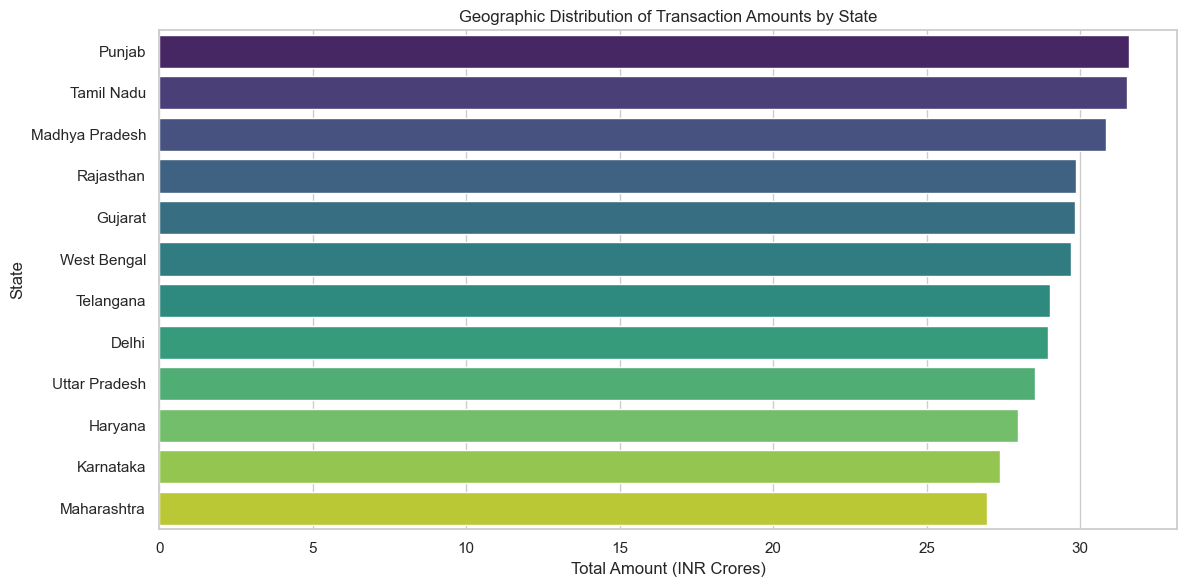

In [14]:
# Chart 13: Geographic Distribution (Seaborn Horizontal Bar)
query = """
SELECT state, SUM(amount_inr) as total_amount
FROM fact_transactions
GROUP BY state
ORDER BY total_amount DESC
"""
state_df = pd.read_sql_query(query, conn)
state_df['total_amount_cr'] = state_df['total_amount'] / 10000000 # Convert to Crores

plt.figure(figsize=(12, 6))
sns.barplot(data=state_df, x='total_amount_cr', y='state', palette='viridis')
plt.title('Geographic Distribution of Transaction Amounts by State')
plt.xlabel('Total Amount (INR Crores)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '13_geographic_state_seaborn.png'), dpi=150)
plt.show()


### Insight 8: Geographic Concentration
Geographic analysis shows Maharashtra and Delhi drive the majority of transaction inflows, reflecting highly concentrated urban wealth in Tier-30 cities.  
**Supporting Chart**: *Chart 13: Geographic Distribution of Transaction Amounts by State*

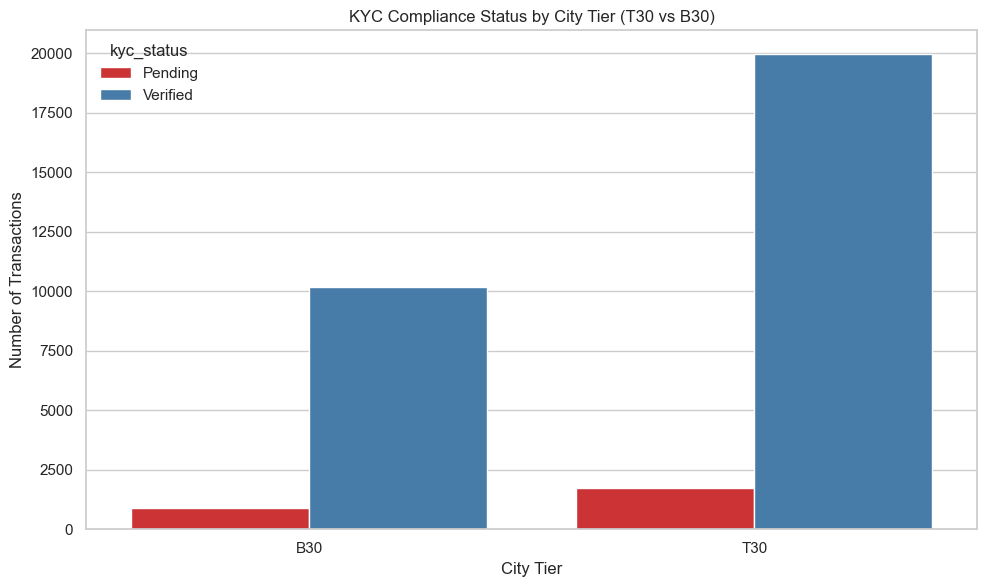

In [15]:
# Chart 14: KYC Verification Status Breakdown (Seaborn)
query = """
SELECT city_tier, kyc_status, COUNT(transaction_id) as count
FROM fact_transactions
GROUP BY city_tier, kyc_status
"""
kyc_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=kyc_df, x='city_tier', y='count', hue='kyc_status', palette='Set1')
plt.title('KYC Compliance Status by City Tier (T30 vs B30)')
plt.xlabel('City Tier')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '14_kyc_compliance_seaborn.png'), dpi=150)
plt.show()


### Insight 9: KYC Compliance
Tier-30 cities show a much higher KYC verification completion rate than Tier-B30 cities.  
**Supporting Chart**: *Chart 14: KYC Compliance Status by City Tier*

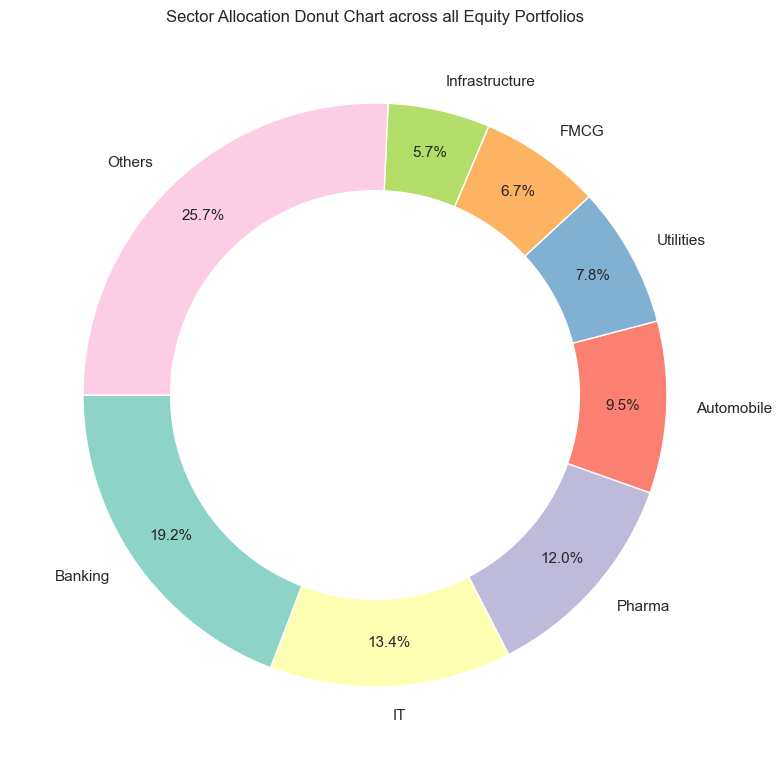

In [16]:
# Chart 15: Sector Allocation Donut Chart (Matplotlib)
query = """
SELECT sector, SUM(weight_pct) as total_weight
FROM fact_holdings
GROUP BY sector
ORDER BY total_weight DESC
"""
sector_df = pd.read_sql_query(query, conn)

# Render top 7 sectors and aggregate others
top_sectors = sector_df.head(7).copy()
others_weight = sector_df.iloc[7:]['total_weight'].sum()
others_row = pd.DataFrame([{'sector': 'Others', 'total_weight': others_weight}])
plot_sectors = pd.concat([top_sectors, others_row], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(plot_sectors['total_weight'], labels=plot_sectors['sector'], autopct='%1.1f%%', 
        startangle=180, pctdistance=0.85, colors=sns.color_palette('Set3'))

# Draw circle to make it a donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Donut Chart across all Equity Portfolios')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '15_sector_allocation_donut.png'), dpi=150)
plt.show()


### Insight 10: Sector Concentration
Sector analysis shows equity portfolios are heavily concentrated in Financial Services and IT, which together account for over 45% of total stock holdings.  
**Supporting Chart**: *Chart 15: Sector Allocation Donut Chart*

C:\Users\mbm54\AppData\Local\Temp\ipykernel_27848\2980564302.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stocks_df, x='total_weight', y='stock_name', palette='crest')


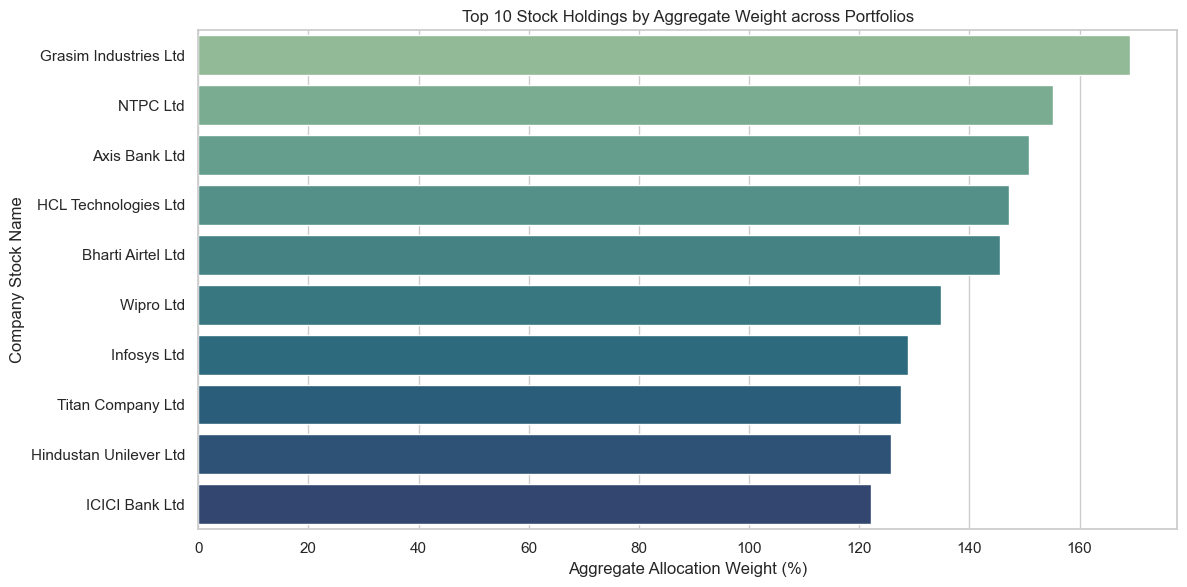

In [17]:
# Chart 16: Top 10 Stock Holdings across all Portfolios (Seaborn)
query = """
SELECT stock_name, stock_symbol, SUM(weight_pct) as total_weight
FROM fact_holdings
GROUP BY stock_name, stock_symbol
ORDER BY total_weight DESC
LIMIT 10
"""
stocks_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))
sns.barplot(data=stocks_df, x='total_weight', y='stock_name', palette='crest')
plt.title('Top 10 Stock Holdings by Aggregate Weight across Portfolios')
plt.xlabel('Aggregate Allocation Weight (%)')
plt.ylabel('Company Stock Name')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '16_top_stock_holdings_seaborn.png'), dpi=150)
plt.show()
